<a href="https://colab.research.google.com/github/thisishasan/speech_processing/blob/main/05_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers peft accelerate sacrebleu rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 16.9 MB/s eta 0:00:00


In [2]:
!pip uninstall -y torchao
!pip install -q --no-cache-dir --force-reinstall "torchao>=0.16.0"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.4 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import torch

BASE_MODEL = "llava-hf/llava-1.5-7b-hf"

ADAPTER_PATH = (
    "/content/drive/MyDrive/01_speech_processing/"
    "sp_exam_project/dataset/hf_llava_checkpoints/final_adapter"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [2]:
from transformers import AutoProcessor, LlavaForConditionalGeneration
from peft import PeftModel

processor = AutoProcessor.from_pretrained(BASE_MODEL)
processor.tokenizer.padding_side = "left"

base_model = LlavaForConditionalGeneration.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_PATH,
    local_files_only=True
)

model.eval()
print("Trained adapter loaded successfully.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Trained adapter loaded successfully.


Saving Top-50-Fundaising-Ideas-for-Nonprofits-768x432.jpg to Top-50-Fundaising-Ideas-for-Nonprofits-768x432.jpg


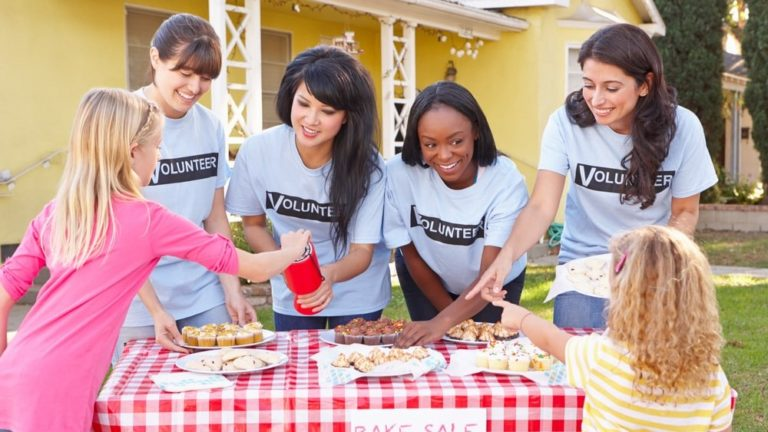

In [14]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

image_path = next(iter(uploaded))
image = Image.open(image_path).convert("RGB")

display(image)

In [16]:
question = input("Enter your question: ")

prompt = f"USER: <image>\n{question} ASSISTANT:"

inputs = processor(
    images=image,
    text=prompt,
    return_tensors="pt",
)

inputs = {
    key: value.to(device) if torch.is_tensor(value) else value
    for key, value in inputs.items()
}

with torch.inference_mode():
    output = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        use_cache=True,
    )

prompt_length = inputs["input_ids"].shape[1]
answer_tokens = output[:, prompt_length:]

predicted_answer = processor.batch_decode(
    answer_tokens,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0].strip()

print("Question:", question)
print("Predicted answer:", predicted_answer)

Enter your question: What evidence suggests that the people are organizing a fundraising event?
Question: What evidence suggests that the people are organizing a fundraising event?
Predicted answer: The presence of a bake sale sign and a table full of baked goods.


In [17]:
reference_answer = input("Enter the correct reference answer: ")

print("Reference answer:", reference_answer)
print("Predicted answer:", predicted_answer)

Enter the correct reference answer: The baked goods, serving table, volunteer shirts, and visible bake-sale sign suggest a fundraising event.
Reference answer: The baked goods, serving table, volunteer shirts, and visible bake-sale sign suggest a fundraising event.
Predicted answer: The presence of a bake sale sign and a table full of baked goods.


In [18]:
import string
from collections import Counter
from sacrebleu import corpus_bleu
from rouge_score import rouge_scorer

def normalize(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return " ".join(text.split())

pred = normalize(predicted_answer)
ref = normalize(reference_answer)

exact_match = float(pred == ref)

relaxed_match = float(
    pred == ref or pred in ref or ref in pred
)

pred_tokens = pred.split()
ref_tokens = ref.split()

common = sum(
    (Counter(pred_tokens) & Counter(ref_tokens)).values()
)

if common == 0:
    token_f1 = 0.0
else:
    precision = common / len(pred_tokens)
    recall = common / len(ref_tokens)
    token_f1 = 2 * precision * recall / (precision + recall)

bleu = corpus_bleu([pred], [[ref]]).score / 100

scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

rouge_l = scorer.score(ref, pred)["rougeL"].fmeasure

print("\nEvaluation metrics:")
print(f"Exact Match:   {exact_match:.4f} ({exact_match * 100:.2f}%)")
print(f"Relaxed Match: {relaxed_match:.4f} ({relaxed_match * 100:.2f}%)")
print(f"Token F1:      {token_f1:.4f} ({token_f1 * 100:.2f}%)")
print(f"BLEU:          {bleu:.4f} ({bleu * 100:.2f}%)")
print(f"ROUGE-L:       {rouge_l:.4f} ({rouge_l * 100:.2f}%)")


Evaluation metrics:
Exact Match:   0.0000 (0.00%)
Relaxed Match: 0.0000 (0.00%)
Token F1:      0.4828 (48.28%)
BLEU:          0.0723 (7.23%)
ROUGE-L:       0.2759 (27.59%)
